# <h1 style="color:blue;">Wine Quality Modelling</h1>

This project aims to model the quality of wine based on physicochemical test results.
We will train and compare four baseline machine learning models:

- k-Nearesr Neighbours (kNN)
- Decision Tree Classifier
- Random Forest Classifier
- eXtreme Gradient Boosting(XGBoost)

The baseline models were chosen based on their frequent usage in existing literature as standatd benchmarks for structured datastes. These models balance interpretability, simplicity and predictive performance, making them appropriate choices for initial evaluation.

The comparison will based on accuracy, classification reports and confusion matrices.


## 1. Import Libaries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight




## 2.Load and Explore Datatset

In [24]:
# Load dataset
red_wine_df = pd.read_csv("winequality-red.csv", sep=";")
white_wine_df = pd.read_csv("winequality-white.csv", sep=";")

#column to indicate wine type
red_wine_df["wine_type"] = "red"
white_wine_df["wine_type"] = "white"

#combine red wine and white wine
wine_df = pd.concat([red_wine_df, white_wine_df], axis = 0, ignore_index=True)

# Group quality scores into 3 categories
wine_df["quality_label"] = wine_df["quality"].apply(lambda q: 0 if q <= 4 else (1 if q <= 6 else 2))

# One-hot encode wine type (0 = red, 1 = white)
wine_df = pd.get_dummies(wine_df, columns=["wine_type"], drop_first=True)

# Split red and white wine datasets
wine_df_red = wine_df[wine_df["wine_type_white"] == 0]
wine_df_white = wine_df[wine_df["wine_type_white"] == 1]

# Dataset overview
print("Dataset shape:", wine_df.shape)
print("\nDataset info:")
print(wine_df.info())
print(wine_df["wine_type_white"].value_counts()) # False = red, True = white
print("\nWine quality counts:\n", wine_df["quality"].value_counts())
print("\nMissing values:\n", wine_df.isnull().sum())


Dataset shape: (6497, 14)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_label         6497 non-null   int64  
 13  wine_type_white       6497 non-null   bool   
dtypes: bool(1), float64(11), int64(

## 3.Data Prepoceesing

In [25]:
def preprocess_data(wine_subset, scale_features=False):
    X = wine_subset.drop(["quality", "quality_label"], axis=1)
    y = wine_subset["quality_label"]
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    if scale_features:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test


## 4. Data Visualization

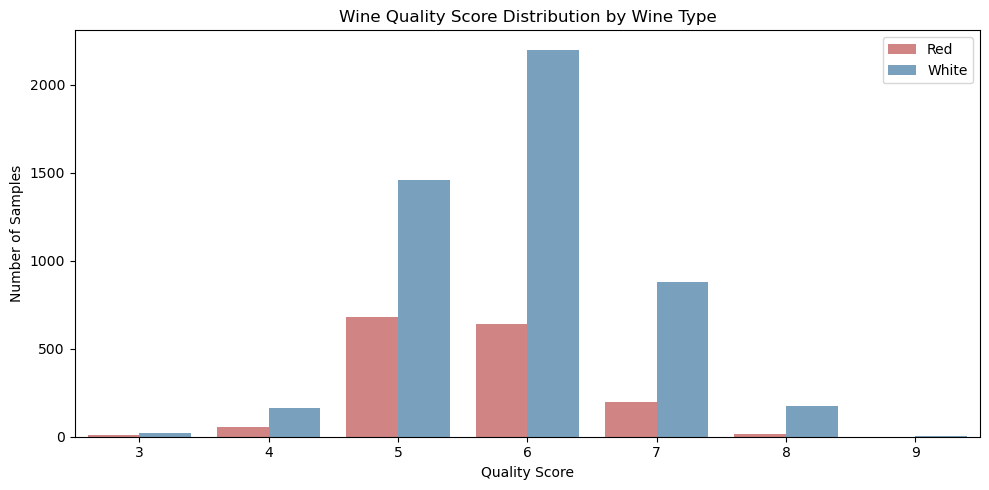

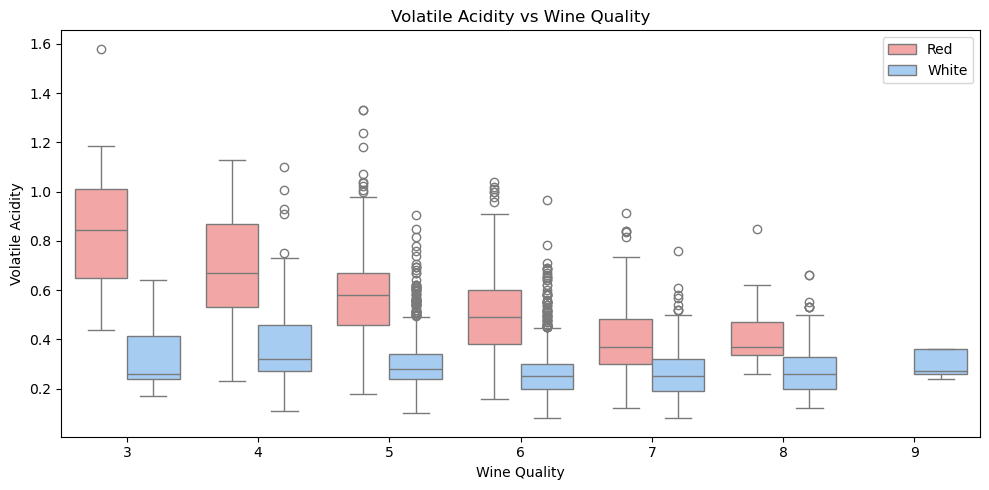

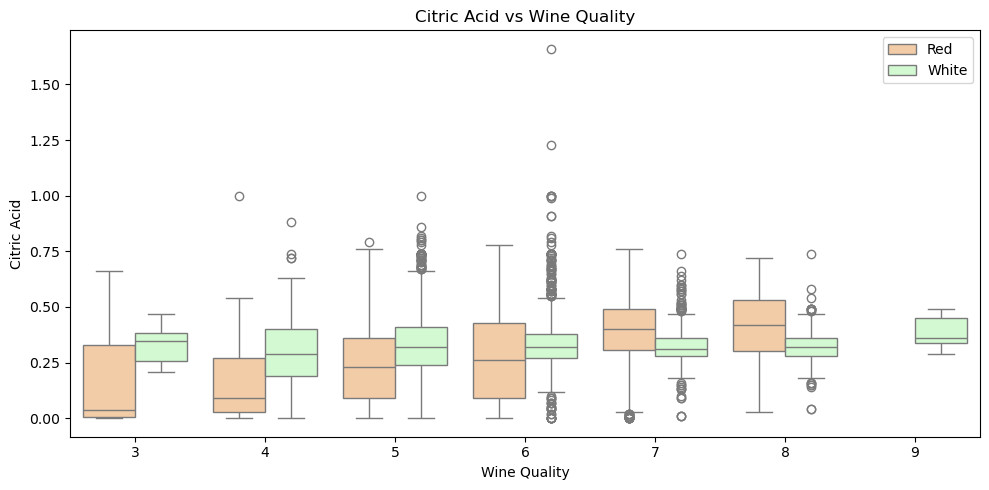

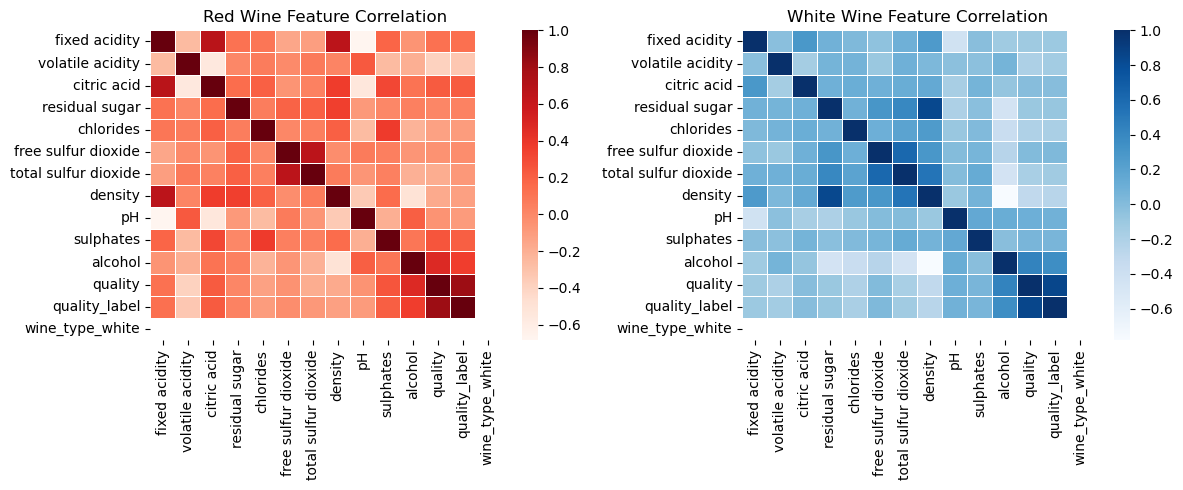

In [26]:
# Class distribution by wine type
plt.figure(figsize=(10, 5))
sns.countplot(x="quality", hue="wine_type_white", data=wine_df, palette=["#DD7777", "#6EA3C9"])

plt.title("Wine Quality Score Distribution by Wine Type")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")
plt.legend(labels=["Red", "White"])
plt.tight_layout()
plt.show()

# Volatile acidity vs quality by wine type
plt.figure(figsize=(10, 5))
sns.boxplot(x="quality", y="volatile acidity", hue="wine_type_white", data=wine_df, palette=["#FF9999", "#99CCFF"])
plt.title("Volatile Acidity vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Volatile Acidity")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Red", "White"]) 
plt.tight_layout()
plt.show()

# Citric acid vs quality by wine type
plt.figure(figsize=(10, 5))
sns.boxplot(x="quality", y="citric acid", hue="wine_type_white", data=wine_df, palette=["#FFCC99", "#CCFFCC"])
plt.title("Citric Acid vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Citric Acid")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Red", "White"]) 
plt.tight_layout()
plt.show()

# Correlation heatmap — show separately for red and white wine
plt.figure(figsize=(12, 5))

# Red wine correlations
plt.subplot(1, 2, 1)
sns.heatmap(wine_df[wine_df["wine_type_white"] == 0].corr(), annot=False, cmap="Reds", linewidths=0.5)
plt.title("Red Wine Feature Correlation")

# White wine correlations
plt.subplot(1, 2, 2)
sns.heatmap(wine_df[wine_df["wine_type_white"] == 1].corr(), annot=False, cmap="Blues", linewidths=0.5)
plt.title("White Wine Feature Correlation")

plt.tight_layout()
plt.show()



## 5. Model Training and Evaluation

The evaluation methodology was experimental, based on partitioning the dataset into training and testing subsets. Each model was trained on the training data and evaluated on unseen testing data using statistical performance metrics including accuracy, precision, recall, and F1-score.


### 5.1 k-Nearest Neighbours (kNN)
We use kNN to predicts the target based on the average of the nearest k Neighbours.


===== kNN - Red Wine =====
Accuracy: 0.8229
Macro-F1: 0.4452 | Weighted-F1: 0.7994 | QWK: 0.3254
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        19
      Medium       0.86      0.93      0.90       396
        High       0.51      0.38      0.44        65

    accuracy                           0.82       480
   macro avg       0.46      0.44      0.45       480
weighted avg       0.78      0.82      0.80       480



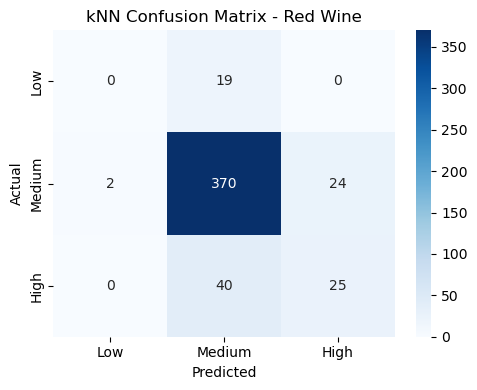


===== kNN - White Wine =====
Accuracy: 0.7884
Macro-F1: 0.5568 | Weighted-F1: 0.7744 | QWK: 0.4369
              precision    recall  f1-score   support

         Low       0.56      0.16      0.25        55
      Medium       0.83      0.90      0.87      1097
        High       0.61      0.50      0.55       318

    accuracy                           0.79      1470
   macro avg       0.67      0.52      0.56      1470
weighted avg       0.77      0.79      0.77      1470



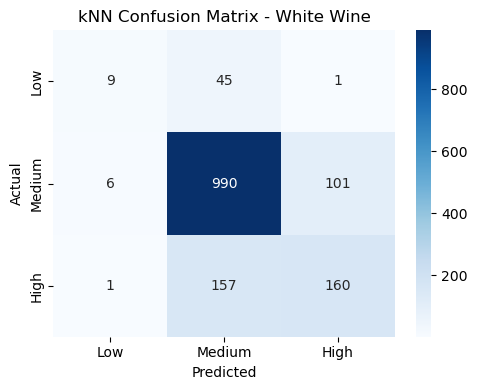

In [27]:
def evaluate_knn(wine_subset, label):
    print(f"\n===== kNN - {label} Wine =====")
    x_train, x_test, y_train, y_test = preprocess_data(wine_subset, scale_features=True)


    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)


    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    qwk = cohen_kappa_score(y_test, y_pred, weights="quadratic")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted_f1:.4f} | QWK: {qwk:.4f}")


    print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))


    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
    plt.title(f"kNN Confusion Matrix - {label} Wine")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

evaluate_knn(wine_df_red, "Red")
evaluate_knn(wine_df_white, "White")


### 5.2 Decision Tree Classifier
A tree-based model that splits feature to predict outcomes.


===== Decision Tree - Red Wine =====
Accuracy: 0.8125
Macro-F1: 0.5423 | Weighted-F1: 0.8149 | QWK: 0.4429
              precision    recall  f1-score   support

         Low       0.19      0.16      0.17        19
      Medium       0.90      0.87      0.89       396
        High       0.52      0.63      0.57        65

    accuracy                           0.81       480
   macro avg       0.54      0.55      0.54       480
weighted avg       0.82      0.81      0.81       480



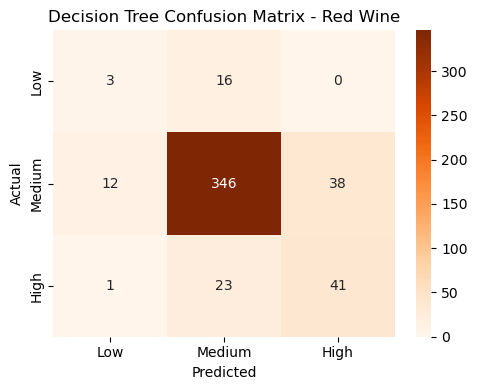


===== Decision Tree - White Wine =====
Accuracy: 0.7721
Macro-F1: 0.5781 | Weighted-F1: 0.7723 | QWK: 0.4640
              precision    recall  f1-score   support

         Low       0.30      0.29      0.30        55
      Medium       0.85      0.85      0.85      1097
        High       0.58      0.59      0.59       318

    accuracy                           0.77      1470
   macro avg       0.58      0.58      0.58      1470
weighted avg       0.77      0.77      0.77      1470



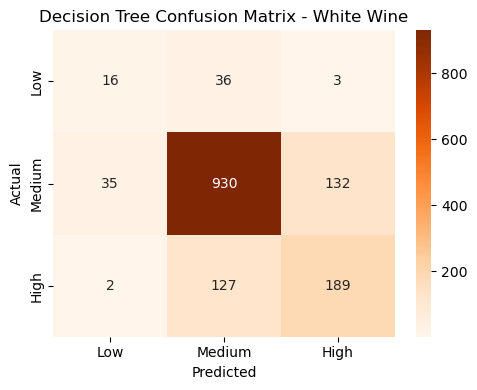

In [28]:
def evaluate_decision_tree(wine_subset, label):
    print(f"\n===== Decision Tree - {label} Wine =====")

    x_train, x_test, y_train, y_test = preprocess_data(wine_subset, scale_features=False)


    dtree = DecisionTreeClassifier(class_weight='balanced',random_state=42)
    dtree.fit(x_train, y_train)
    y_pred = dtree.predict(x_test)

    acc       = accuracy_score(y_test, y_pred)
    macro_f1  = f1_score(y_test, y_pred, average="macro")
    weighted  = f1_score(y_test, y_pred, average="weighted")
    qwk       = cohen_kappa_score(y_test, y_pred, weights="quadratic")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted:.4f} | QWK: {qwk:.4f}")

    print(classification_report(y_test, y_pred, target_names=["Low","Medium","High"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Oranges",
                xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
    plt.title(f"Decision Tree Confusion Matrix - {label} Wine")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

evaluate_decision_tree(wine_df_red, "Red")
evaluate_decision_tree(wine_df_white, "White")



### 5.3 Random Forest Classifier

An ensemble of decision trees that improves accuracy and reduces overfitting.



===== Random Forest - Red Wine =====
Accuracy: 0.8708
Macro-F1: 0.5188 | Weighted-F1: 0.8486 | QWK: 0.5032

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        19
      Medium       0.89      0.96      0.92       396
        High       0.73      0.55      0.63        65

    accuracy                           0.87       480
   macro avg       0.54      0.51      0.52       480
weighted avg       0.83      0.87      0.85       480



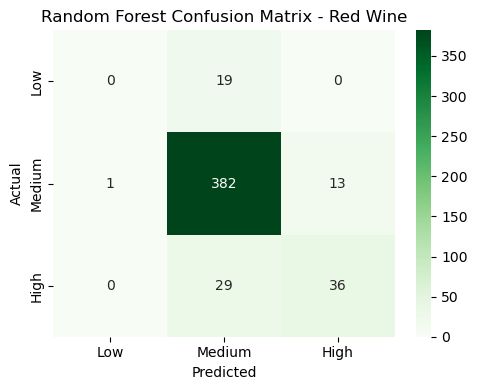


===== Random Forest - White Wine =====
Accuracy: 0.8381
Macro-F1: 0.5908 | Weighted-F1: 0.8201 | QWK: 0.5523

              precision    recall  f1-score   support

         Low       0.78      0.13      0.22        55
      Medium       0.85      0.95      0.90      1097
        High       0.79      0.56      0.66       318

    accuracy                           0.84      1470
   macro avg       0.80      0.55      0.59      1470
weighted avg       0.83      0.84      0.82      1470



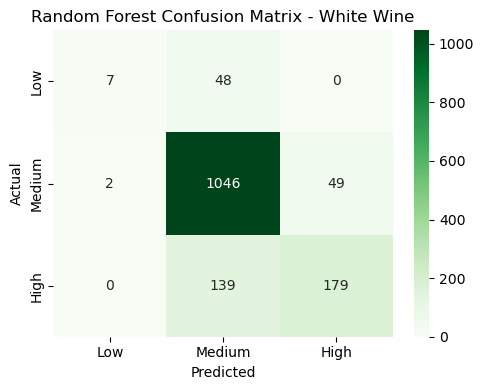

In [29]:
def evaluate_random_forest(wine_subset, label):
    print(f"\n===== Random Forest - {label} Wine =====")
    x_train, x_test, y_train, y_test = preprocess_data(wine_subset, scale_features=False)

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)

    acc       = accuracy_score(y_test, y_pred)
    macro_f1  = f1_score(y_test, y_pred, average="macro")
    weighted  = f1_score(y_test, y_pred, average="weighted")
    qwk       = cohen_kappa_score(y_test, y_pred, weights="quadratic")
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro-F1: {macro_f1:.4f} | Weighted-F1: {weighted:.4f} | QWK: {qwk:.4f}\n")

    print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
    plt.title(f"Random Forest Confusion Matrix - {label} Wine")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Run Random Forest comparisons
evaluate_random_forest(wine_df_red, "Red")
evaluate_random_forest(wine_df_white, "White")



### 5.4 eXtreme Gradient Boosting(XGBoost)

An optimized gradient boosting algorithm that improves model performance by sequentially building weak learners


===== XGBoost - Red Wine =====
Accuracy: 0.85
Macro-F1: 0.59 | Weighted-F1: 0.84 | QWK: 0.54

              precision    recall  f1-score   support

           0       0.43      0.16      0.23        19
           1       0.91      0.90      0.91       396
           2       0.57      0.72      0.64        65

    accuracy                           0.85       480
   macro avg       0.64      0.59      0.59       480
weighted avg       0.85      0.85      0.84       480



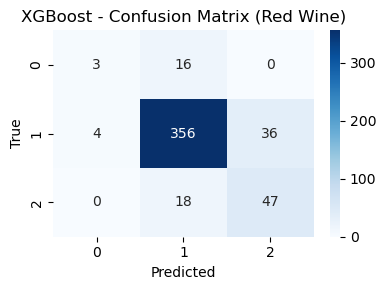

===== XGBoost - White Wine =====
Accuracy: 0.80
Macro-F1: 0.65 | Weighted-F1: 0.80 | QWK: 0.55

              precision    recall  f1-score   support

           0       0.46      0.40      0.43        55
           1       0.88      0.85      0.87      1097
           2       0.62      0.69      0.65       318

    accuracy                           0.80      1470
   macro avg       0.65      0.65      0.65      1470
weighted avg       0.81      0.80      0.80      1470



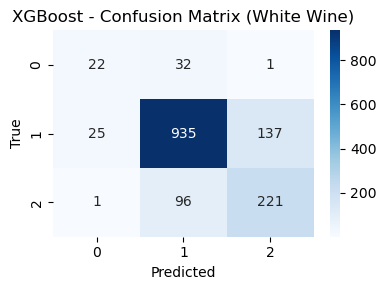

In [18]:
def run_xgb_on_df(df: pd.DataFrame, dataset_name="ALL", test_size=0.30, random_state=42):
    y = df["quality_label"].astype(int).values
    X = df.drop(columns=["quality", "quality_label"]).values 

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    w_train = compute_sample_weight(class_weight="balanced", y=y_train)

    xgb = XGBClassifier(random_state=42)

    xgb.fit(X_train, y_train, sample_weight=w_train)
    y_pred = xgb.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    qwk = cohen_kappa_score(y_test, y_pred, weights="quadratic")

    print(f"===== XGBoost - {dataset_name} =====")
    print(f"Accuracy: {acc:.2f}")
    print(f"Macro-F1: {f1_macro:.2f} | Weighted-F1: {f1_weighted:.2f} | QWK: {qwk:.2f}\n")
    print(classification_report(y_test, y_pred, digits=2))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"XGBoost - Confusion Matrix ({dataset_name})")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

_ = run_xgb_on_df(wine_df_red,   dataset_name="Red Wine")
_ = run_xgb_on_df(wine_df_white, dataset_name="White Wine")


## 6.Model Metrics Summary (Accuracy, Precison, Recall, F1)

In [31]:
def build_metrics_summary(y_test, y_pred_knn, y_pred_dtree, y_pred_rforest, y_pred_xgb, label):
    metrics = {
        "k-Nearest Neighbors": {
            "Accuracy": accuracy_score(y_test, y_pred_knn),
            "Precision": precision_score(y_test, y_pred_knn, average='weighted'),
            "Recall": recall_score(y_test, y_pred_knn, average='weighted'),
            "F1-score": f1_score(y_test, y_pred_knn, average='weighted'),
            "QWK":cohen_kappa_score(y_test, y_pred_knn, weights="quadratic")
        },
        "Decision Tree": {
            "Accuracy": accuracy_score(y_test, y_pred_dtree),
            "Precision": precision_score(y_test, y_pred_dtree, average='weighted'),
            "Recall": recall_score(y_test, y_pred_dtree, average='weighted'),
            "F1-score": f1_score(y_test, y_pred_dtree, average='weighted'),
            "QWK":cohen_kappa_score(y_test, y_pred_dtree, weights="quadratic")
        },
        "Random Forest": {
            "Accuracy": accuracy_score(y_test, y_pred_rforest),
            "Precision": precision_score(y_test, y_pred_rforest, average='weighted'),
            "Recall": recall_score(y_test, y_pred_rforest, average='weighted'),
            "F1-score": f1_score(y_test, y_pred_rforest, average='weighted'),
            "QWK":cohen_kappa_score(y_test, y_pred_rforest, weights="quadratic")
        },
        "XGBoost": {  
            "Accuracy": accuracy_score(y_test, y_pred_xgb),
            "Precision": precision_score(y_test, y_pred_xgb, average='weighted'),
            "Recall": recall_score(y_test, y_pred_xgb, average='weighted'),
            "F1-score": f1_score(y_test, y_pred_xgb, average='weighted'),
            "QWK":cohen_kappa_score(y_test, y_pred_xgb, weights="quadratic")
        }
    }

    df = pd.DataFrame(metrics).T
    percent_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    df[percent_cols] = (df[percent_cols] * 100).round(2)
    

    df['QWK'] = df['QWK'].round(4)


    print(f"\n===== Summary Table - {label} Wine =====")
    display(df)
    return df


## 6.1 Red Wine Metrics Summary

In [32]:
x_train_red_scaled, x_test_red_scaled, y_train_red, y_test_red = preprocess_data(wine_df_red, scale_features=True)
x_train_red_unscaled, x_test_red_unscaled, _, _ = preprocess_data(wine_df_red, scale_features=False)
w_train_red = compute_sample_weight(class_weight="balanced", y=y_train_red)

knn_red = KNeighborsClassifier(n_neighbors=5)
knn_red.fit(x_train_red_scaled, y_train_red)
y_pred_knn_red = knn_red.predict(x_test_red_scaled)

dtree_red = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtree_red.fit(x_train_red_unscaled, y_train_red)
y_pred_dtree_red = dtree_red.predict(x_test_red_unscaled)

rf_red = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_red.fit(x_train_red_unscaled, y_train_red)
y_pred_rforest_red = rf_red.predict(x_test_red_unscaled)


xgb_red = XGBClassifier(random_state=42)
xgb_red.fit(x_train_red_unscaled, y_train_red, sample_weight=w_train_red)
y_pred_xgb_red = xgb_red.predict(x_test_red_unscaled)

# Build summary
metrics_red = build_metrics_summary(y_test_red, y_pred_knn_red, y_pred_dtree_red, y_pred_rforest_red, y_pred_xgb_red, "Red")



===== Summary Table - Red Wine =====


,Accuracy,Precision,Recall,F1-score,QWK
k-Nearest Neighbors,82.29,78.06,82.29,79.94,0.3254
Decision Tree,81.25,81.91,81.25,81.49,0.4429
Random Forest,87.08,83.24,87.08,84.86,0.5032
XGBoost,84.58,84.67,84.58,84.25,0.5359


## 6.2 White Wine Metrcis Summary

In [33]:
x_train_white_scaled, x_test_white_scaled, y_train_white, y_test_white = preprocess_data(wine_df_white, scale_features=True)
x_train_white_unscaled, x_test_white_unscaled, _, _ = preprocess_data(wine_df_white, scale_features=False)
w_train_white = compute_sample_weight(class_weight="balanced", y=y_train_white)

knn_white = KNeighborsClassifier(n_neighbors=5)
knn_white.fit(x_train_white_scaled, y_train_white)
y_pred_knn_white = knn_white.predict(x_test_white_scaled)

dtree_white = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtree_white.fit(x_train_white_unscaled, y_train_white)
y_pred_dtree_white = dtree_white.predict(x_test_white_unscaled)

rf_white = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_white.fit(x_train_white_unscaled, y_train_white)
y_pred_rforest_white = rf_white.predict(x_test_white_unscaled)

xgb_white = XGBClassifier(random_state=42)
xgb_white.fit(x_train_white_unscaled, y_train_white, sample_weight=w_train_white)
y_pred_xgb_white = xgb_white.predict(x_test_white_unscaled)

# Build summary
metrics_white = build_metrics_summary(y_test_white, y_pred_knn_white, y_pred_dtree_white, y_pred_rforest_white, y_pred_xgb_white, "White")



===== Summary Table - White Wine =====


,Accuracy,Precision,Recall,F1-score,QWK
k-Nearest Neighbors,78.84,77.29,78.84,77.44,0.4369
Decision Tree,77.21,77.25,77.21,77.23,0.4640
Random Forest,83.81,83.20,83.81,82.01,0.5523
XGBoost,80.14,80.67,80.14,80.33,0.5544


## 7. Model Visual Comparisom (Bar Chat)

C:\Users\dogeg\AppData\Local\Temp\ipykernel_25700\3423272457.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Model", y="Score", hue="Wine Type", data=melted_df, ci=None, edgecolor="black")


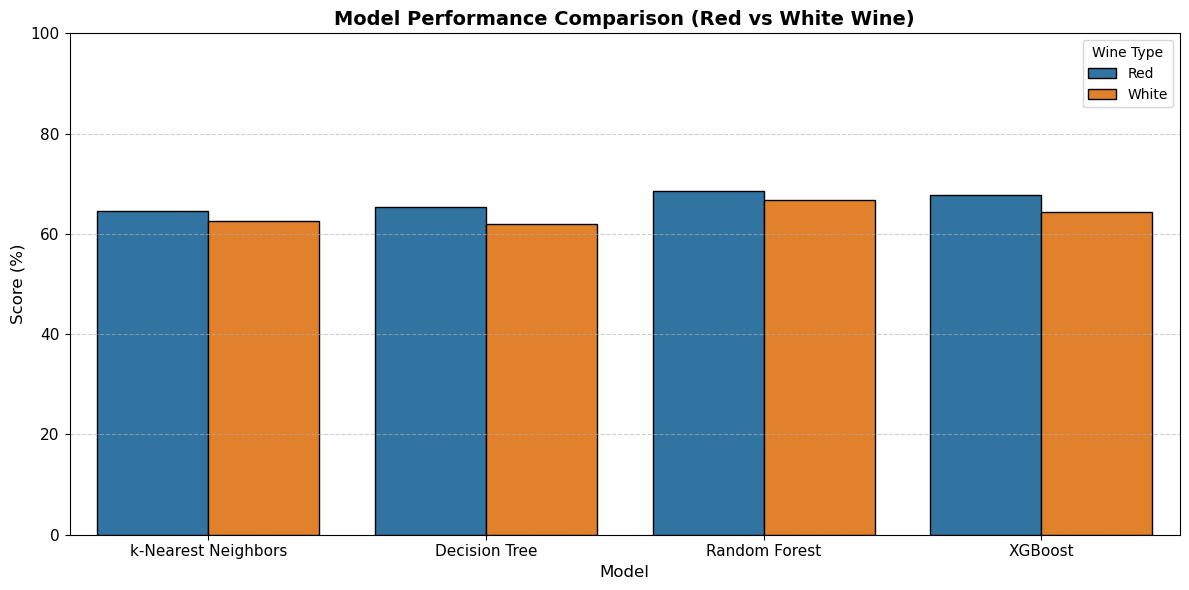

In [34]:
# Add a column for wine type
metrics_red["Wine Type"] = "Red"
metrics_white["Wine Type"] = "White"

# Reset index to turn model name into a column
metrics_red = metrics_red.reset_index().rename(columns={"index": "Model"})
metrics_white = metrics_white.reset_index().rename(columns={"index": "Model"})

# Combine the two tables
combined_df = pd.concat([metrics_red, metrics_white], axis=0)

# Melt the dataframe for plotting
melted_df = combined_df.melt(id_vars=["Model", "Wine Type"], var_name="Metric", value_name="Score")

# Plot using seaborn
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Score", hue="Wine Type", data=melted_df, ci=None, edgecolor="black")

plt.title("Model Performance Comparison (Red vs White Wine)", fontsize=14, weight='bold')
plt.ylabel("Score (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Wine Type", loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()



## Model Evaluation and Comparison

Three baseline models — k-Nearest Neighbors (kNN), Decision Tree, Random Forest,and eXtreme Gradient Boosting(XGBoost) — were trained and evaluated on the Wine Quality Dataset.

The models were evaluated using the following metrics:

- **Accuracy**: Overall correctness of the model.
- **Precision**: How many predicted positive cases were actually positive.
- **Recall**: How many actual positive cases were correctly predicted.
- **F1-Score**: Harmonic mean of Precision and Recall, balancing both metrics.
- **QWK (Quadratic Weighted Kappa)**: Measure of agreement between predictions and actuals for ordered categories, which penalizes larger errors more heavily than smaller ones.

A stratified 70%-30% train-test split was applied to maintain label distribution. StandardScaler was used to scale the input features for kNN due to its sensitivity to feature magnitudes.

## Results Analysis

The tables below compare the performance of each model on Red and White wine datasets:

Red Wine Results

| Model                | Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) |      QWK     |
|----------------------|--------------|---------------|------------|--------------|--------------|
| k-Nearest Neighbors   | 82.29       | 78.06         | 82.29      | 79.94        | 0.4369       |
| Decision Tree         | 81.25       | 81.91         | 81.25      | 81.49        | 0.4429       |
| Random Forest         | 87.08       | 83.24         | 87.08      | 84.86        | 0.5032       |
| XGBoost               | 84.58       | 84.67         | 84.58      | 84.25        | 0.5359       |

White Wine Results

| Model                | Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) |      QWK     |
|----------------------|--------------|---------------|------------|--------------|--------------|
| k-Nearest Neighbors   | 78.84       | 77.29         | 78.84      | 77.44        | 0.3254       |
| Decision Tree         | 77.21       | 77.25         | 77.21      | 77.23        | 0.4640       |
| Random Forest         | 83.81       | 83.20         | 83.81      | 82.01        | 0.5523       |
| XGBoost               | 80.14       | 80.67         | 80.14      | 80.33        | 0.5544       |


### Observations:
- For both wine types, **Random Forest** consistently achieved the highest performance across all evaluation metrics, demonstrating its robustness and ability to generalize well, even in the presence of minor class imbalance.
- Red wine models consistently outperformed white wine models across all classifier
- kNN showed competitive performance in both cases, but with slightly lower precision than Random Forest, possibly due to its sensitivity to feature distributions and scaling.
- Decision Tree, while simple and interpretable, had the lowest accuracy overall — highlighting its tendency to overfit compared to ensemble methods.
- XGBoost also demonstrated strong performance, particularly in terms of QWK and the recall rate for minority type , positioning it as a powerful alternative to Random Forest, especially for the red wine dataset.


## Discussion
Based on the experimental results, Random Forest consistently outperformed both Decision Tree and k-Nearest Neighbors across all evaluation metrics for both red and white wine datasets. Its ensemble approach provided strong generalization and reduced overfitting, achieving the highest accuracy and class balance—especially on red wine. XGBoost delivered competitive results—typically second to Random Forest on Accuracy/weighted F1 —but it showed the best class balance, with the highest macro-F1 and QWK. When minority-class performance matters, XGBoost is preferred. Decision Tree showed the lowest overall performance, particularly on white wine, likely due to overfitting and limited robustness. k-Nearest Neighbors (kNN) achieved moderate results, performing better on red wine than white, but remained sensitive to feature scaling and local variations. These findings are consistent with existing research, where Random Forest is widely recognized for its reliability and effectiveness, especially in structured classification problems like wine quality prediction.



In this project, four baseline machine learning models—k-Nearest Neighbors (kNN), Decision Tree, Random Forest, and XGBoost—were developed and evaluated to predict wine quality using physicochemical attributes, for both red and white wine datasets.

The experimental results showed that Random Forest consistently outperformed the other models across overall evaluation metrics for both wine types. For red wine, it achieved an accuracy of 87.08% and a weighted F1-score of 85.11%, while for white wine, it achieved 83.81% accuracy and 82.49% weighted F1-score. XGBoost was close behind in overall metrics (Red: 84.58% Acc, 84.25% weighted F1; White: 80.14% Acc, 80.33% weighted F1) and provided the best balance across classes, as reflected by the highest macro-F1 and QWK. k-Nearest Neighbors performed competitively, achieving 82.29% accuracy on red wine and 78.84% on white wine, though it showed slightly lower precision than Random Forest—likely due to its sensitivity to local data distributions and feature scaling. Decision Tree, while simple and interpretable, had the lowest accuracy in both cases (81.25% for red, 77.21% for white), reinforcing its tendency to overfit when compared to ensemble methods.

Overall, the study confirms that ensemble methods like Random Forest—and, when minority-class performance is critical, XGBoost—are particularly effective for structured classification tasks such as wine quality prediction.
